### Project introduction, motivation, and goals

Generative adversarial networks (GANs) are used for image tasks including style transfer, super-resolution, and domain adaptation. CycleGAN extends these possibilities by enabling image-to-image translation without paired training data, with applications in art style conversion, medical imaging, and satellite imagery.

The Monet2Photo model is one of the most widely used pretrained CycleGAN examples, providing an accessible setting to explore how unpaired translation models behave in practice. Even with a pretrained model, important questions arise: How well does it generalize to new paintings? Does translation quality change when applied outside the original training style? Which evaluation methods best capture what the model has learned?

This project serves as a comprehensive case study in evaluating the pretrained Monet2Photo CycleGAN, focusing on two central questions:

1. Model generalization: How does the Monet-trained model perform on unseen Monet test paintings versus paintings from a different artist like Cezanne? While prior work has explored this, we conduct our own systematic evaluation to understand these generalization effects.
2. Evaluation methodology: How do quantitative metrics such as FID, qualitative inspection, and feature space visualizations provide complementary insights into model performance? We investigate situations where metric scores and visual quality diverge.

Our approach follows a structured evaluation framework using established techniques and includes the following steps:
- Apply the pretrained Monet2Photo CycleGAN to test paintings from Monet and Cezanne
- Evaluate translation quality with multiple metrics and compare with literature baselines
- Use visualizations to explore what transformations the model learns
- Discuss metric limitations by contrasting training and test performance

### EDA (???)

### Expectations for pretrained Monet2Photo CycleGAN

Before running our chosen pretrained Monet2Photo model and evaluating its outputs qualitatively as well as quantitatively, we established the following expectations for the pretrained CycleGAN on the painting-to-photo image translation task.

Functional expectations:
- The model should work as intended and successfully generate output images from input paintings without errors
- The generated images should visually resemble real photographs rather than paintings, e.g., without brush strokes or artistic style elements
- The content of the generated images should maintain the same semantic context and composition as the original paintings

Quality expectations:
- The output quality will be limited by the model's resolution of 256 x 256 pixels, fine details may be lost

Generalization expectations:
- The model should be able to generalize well and create somewhat photo-realistic images from the unseen test data
- When tested against multiple artists, the generated images from Monet paintings should be more realistic than images created from Cezanne paintings as the model was pretrained on Monet paintings

### Setup of pretrained Monet2Photo CycleGAN

To set up the pretrained CycleGAN, we first clone the model's repository and install required libraries.

In [ ]:
# Clone the repository and nanvigate into the directory
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd pytorch-CycleGAN-and-pix2pix

c:\Users\Yoshio\OneDrive\Bildung\Master (CBS)\Semester-03\Advanced ML for CV\final_project\Advanced-Machine-Learning-for-Computer-Vision\pytorch-CycleGAN-and-pix2pix


Cloning into 'pytorch-CycleGAN-and-pix2pix'...


In [ ]:
# !pip install torch torchvision torchaudio
# !pip install dominate visdom wandb
# !pip install kagglehub

Next, we get the checkpoints for the pretrained model.

In [2]:
import urllib.request
import zipfile
import os

# Create directory
os.makedirs("checkpoints/monet2photo_pretrained", exist_ok=True)

# Download pretrained model
urllib.request.urlretrieve(
    "http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/monet2photo.pth",
    "checkpoints/monet2photo_pretrained/latest_net_G.pth"
)

('checkpoints/monet2photo_pretrained/latest_net_G.pth',
 <http.client.HTTPMessage at 0x2033df85310>)

Then, the datasets Monet2Photo and Cezanne2Photo are downloaded. Each dataset is saved into a dedicated folder, extracted, and the original zip file is removed to keep the directory clean.

In [ ]:
# Download Monet2Photo
os.makedirs("datasets", exist_ok=True)
urllib.request.urlretrieve(
    "http://efrosgans.eecs.berkeley.edu/cyclegan/datasets/monet2photo.zip",
    "datasets/monet2photo.zip"
)
with zipfile.ZipFile("datasets/monet2photo.zip", 'r') as zip_ref:
    zip_ref.extractall("datasets/")
os.remove("datasets/monet2photo.zip")

In [ ]:
# Same for Cezanne2Photo
urllib.request.urlretrieve(
    "http://efrosgans.eecs.berkeley.edu/cyclegan/datasets/cezanne2photo.zip",
    "datasets/cezanne2photo.zip"
)
with zipfile.ZipFile("datasets/cezanne2photo.zip", 'r') as zip_ref:
    zip_ref.extractall("datasets/")
os.remove("datasets/cezanne2photo.zip")

The datasets contain the following amounts of paintings and real images:

| Dataset | Train paintings | Train real images | Test paintings | Test real images |
|---------|-----------------|-------------|-----------|-----------|
| Monet | 1072 | 6287 | 121 | 751 |
| Cezanne | 525 | 6287 | 58 | 751 |

The datasets contain imbalanced sample sizes, with Monet having almost twice as many training paintings (1072) as Cezanne (525), though both share the same real photo collection (6287 training, 751 test). The test sets are also imbalanced (Monet: 121, Cezanne: 58). These sample size differences, particularly the small Cezanne test set, may affect the reliability and comparability of quantitative metrics between the two artists.

Now we run the model on unseen test paintings from Monet and paintings from Cezanne.

In [ ]:
# Test on previously unseen Monet paintings
!python test.py --dataroot datasets/monet2photo/testA --name monet2photo_pretrained --model test --no_dropout --num_test 121 --phase test_monet

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: datasets/monet2photo/testA    	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

In [ ]:
# Test on Cezanne paintings
!python test.py --dataroot datasets/cezanne2photo/testA --name monet2photo_pretrained --model test --no_dropout --num_test 58 --phase test_cezanne

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: datasets/cezanne2photo/testA  	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

### Qualitative evaluation of the generated images

To be able to compare the input image and the generated image next to each other, the following function is defined.

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

def compare_single_pair(real_path, fake_path, figsize=(12, 6)):
    """ Display one pair of real and fake images side-by-side """
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Load images
    real_img = Image.open(real_path)
    fake_img = Image.open(fake_path)
    
    # Display images
    axes[0].imshow(real_img)
    axes[0].set_title("Original")
    axes[0].axis("off")
    
    axes[1].imshow(fake_img)
    axes[1].set_title("Generated")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

First, we take a look at examples for photo-realistic images created from Monet paintings.

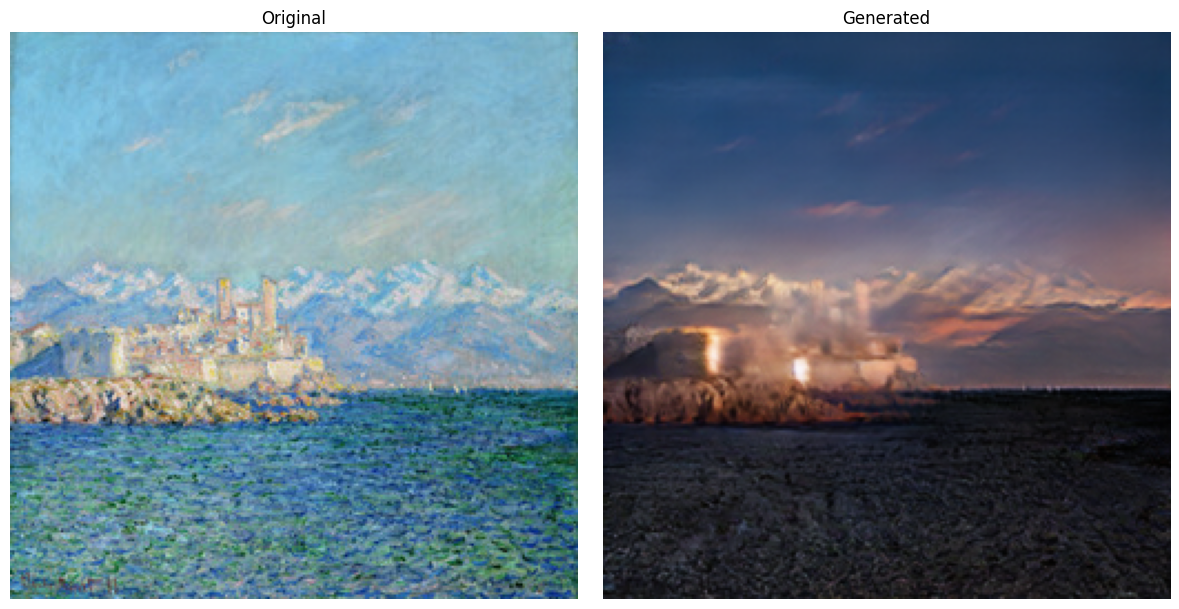

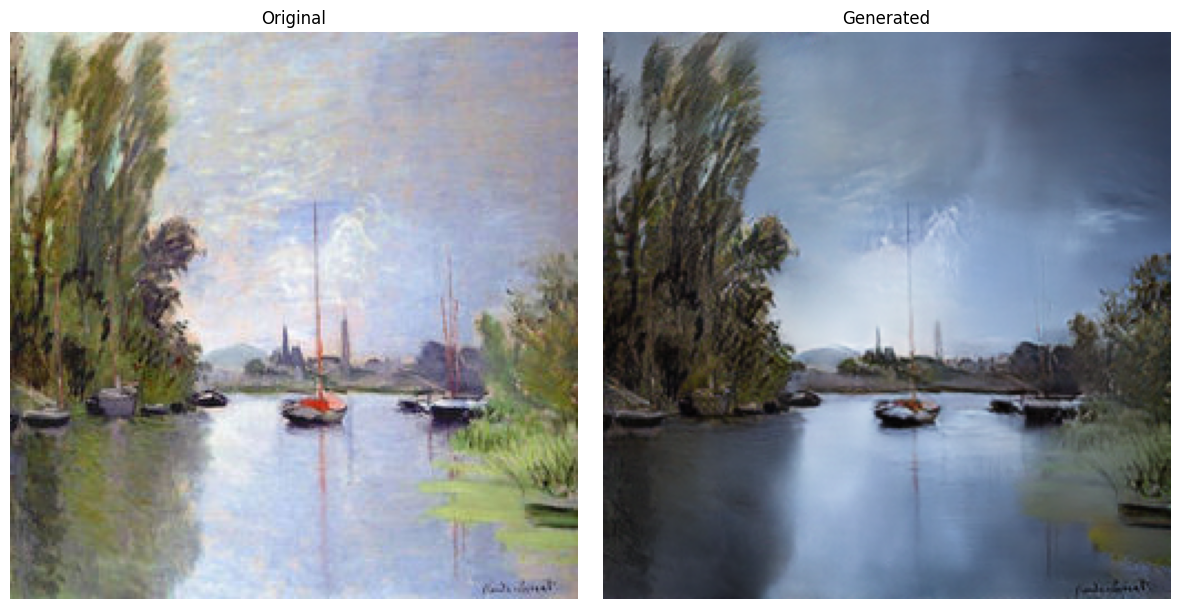

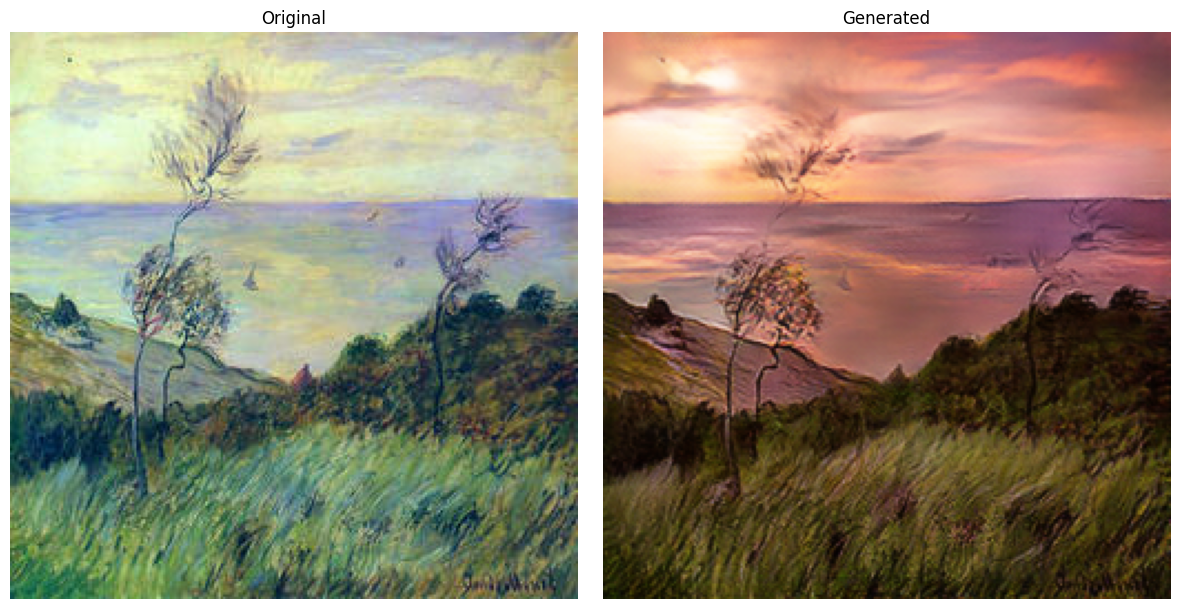

In [5]:
compare_single_pair("results/monet2photo_pretrained/test_monet_latest/images/00020_real.png",
                    "results/monet2photo_pretrained/test_monet_latest/images/00020_fake.png")

compare_single_pair("results/monet2photo_pretrained/test_monet_latest/images/00030_real.png",
                    "results/monet2photo_pretrained/test_monet_latest/images/00030_fake.png")

compare_single_pair("results/monet2photo_pretrained/test_monet_latest/images/00170_real.png",
                    "results/monet2photo_pretrained/test_monet_latest/images/00170_fake.png")

Now, we look at somewhat comparable images generated from Cezanne paintings.

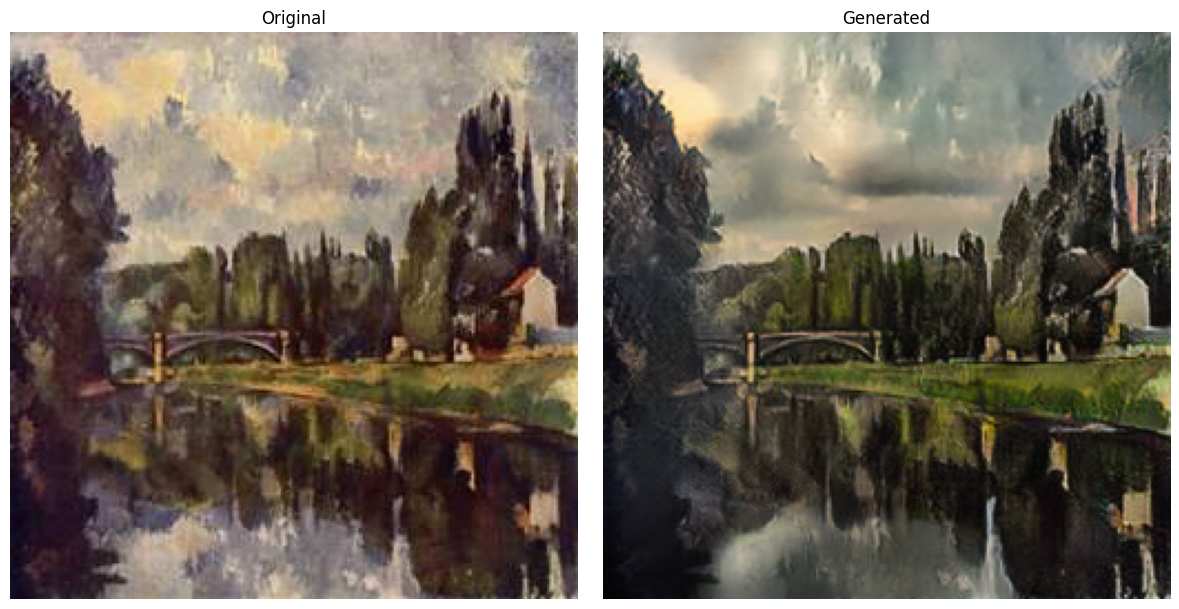

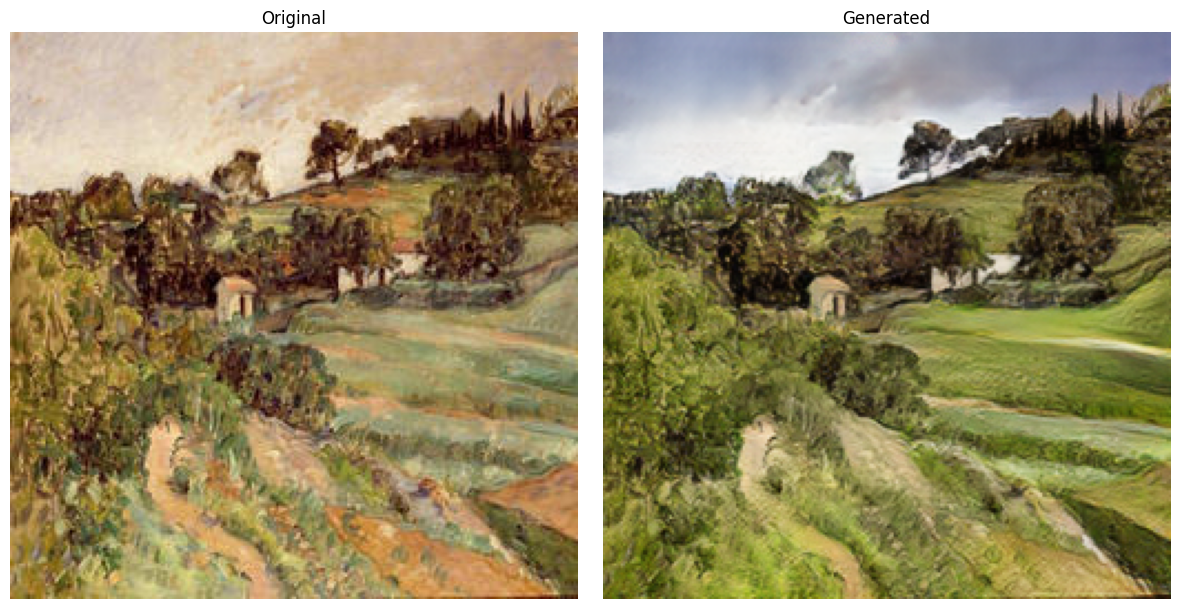

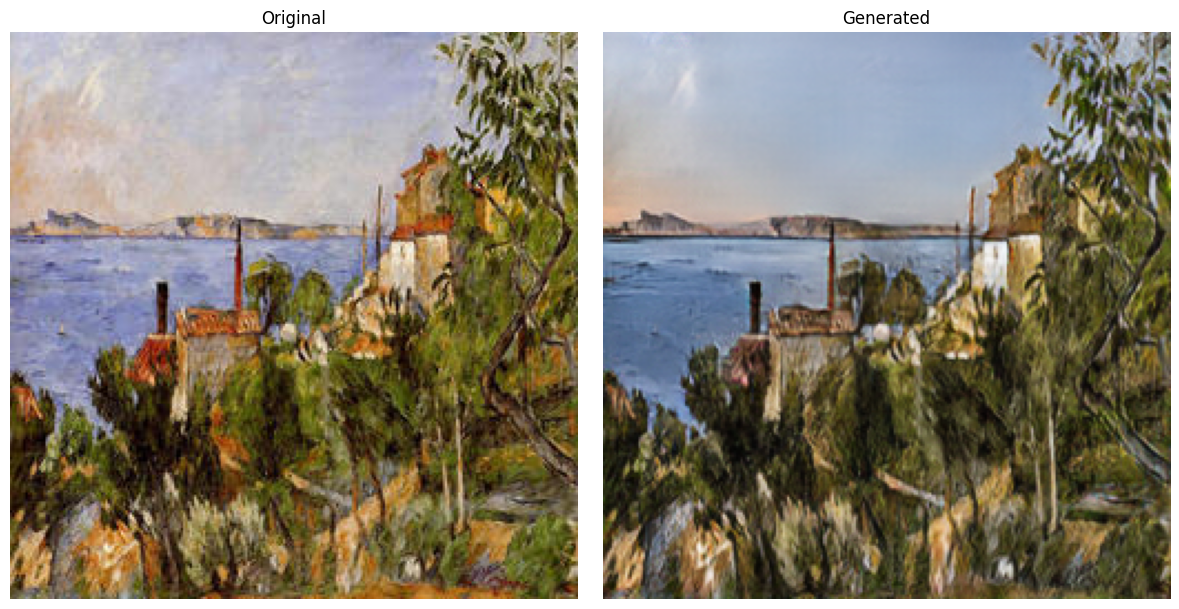

In [35]:
compare_single_pair("results/monet2photo_pretrained/test_cezanne_latest/images/00100_real.png",
                    "results/monet2photo_pretrained/test_cezanne_latest/images/00100_fake.png")

compare_single_pair("results/monet2photo_pretrained/test_cezanne_latest/images/00220_real.png",
                    "results/monet2photo_pretrained/test_cezanne_latest/images/00220_fake.png")

compare_single_pair("results/monet2photo_pretrained/test_cezanne_latest/images/00230_real.png",
                    "results/monet2photo_pretrained/test_cezanne_latest/images/00230_fake.png")

The initial qualitative evaluation confirms the expectations established before running the model:
- The functionality works as intended, the generated images for Monet resemble real photographs rather than paintings, and the content maintains the same semantic context and composition as the original paintings
- The quality is limited by the 256 x 256 resolution and the generated images lack sharpness
- The model generalizes well to unseen test data from Monet, these appear more realistic than those from Cezanne paintings
    - The quality and texture of generated Cezanne photos is worse, with more brush-stroke like images and less distinct surface differentiation
    - The color translations of Monet images are more balanced and more realistic
    - Lighting and atmosphere in Cezanne pictures appear less consistent with photographic imaging

This sets the stage for quantitative evaluation. Since we confirmed the model works as expected, we now want to investigate:
- Whether performance on Monet paintings is comparable to established baselines from literature
- How the model performs on the limited amounts of test data compared to training data and what this reveals about generalization
- Whether metrics reflect our qualitative observations that Monet samples appear more realistic than Cezanne samples
- Whether commonly used metrics like FID appropriately capture the translation quality and photorealism we observed visually, and whether alternative metrics like LPIPS provide complementary insights
- Whether feature space visualizations show generated images clustering closer to real photographs than to original paintings, with Monet-generated images positioned closer to the photorealistic domain than Cezanne-generated images

Based on our qualitative observations and the project goals, we expect:
- FID scores for Monet test paintings comparable to literature baselines
- Some performance degradation on test data compared to training data due to smaller sample size and natural generalization gap
- Better metric scores for Monet-generated images compared to Cezanne-generated images
- In feature space visualizations, generated images should position between paintings and real photos, closer to the photorealistic domain, with Monet translations showing stronger movement toward real photos than Cezanne translations

### Quantitative evaluation of the generated images

Quantitatively evaluating generative adversarial networks remains challenging due to several fundamental issues. While human evaluation provides intuitive assessment of visual quality, it is expensive, subjective, and cannot reliably detect problems like mode collapse where models sacrifice diversity for sample quality. Quantitative metrics offer reproducibility but often fail to align with human perceptual judgment, and the lack of paired ground truth data makes evaluation particularly difficult for unpaired translation tasks (https://arxiv.org/pdf/1802.03446).

Nevertheless, there have been many quantitative metrics that have been employed. An early and popular evaluation metric is the Inception Score (IS), which measures both image quality and diversity by analyzing class prediction distributions from an ImageNet-trained Inception network. However, IS has been widely criticized for significant limitations as it ignores the real data distribution entirely, examining only generated samples, fails to detect intra-class mode collapse and therefore achieving high scores even when generating only one image per class, and it suffers from severe dataset mismatch when applied to non-ImageNet domains. Additionally, IS can be artificially maximized to near-perfect scores through gradient-based optimization without improving visual quality (https://arxiv.org/pdf/1801.01973). These shortcomings led the field to adopt the Fréchet Inception Distance (FID) as the standard metric. Introduced by (https://proceedings.neurips.cc/paper_files/paper/2017/file/8a1d694707eb0fefe65871369074926d-Paper.pdf), FID measures the Wasserstein-2 distance between Gaussian distributions fitted to Inception features from real and generated images. Unlike IS, FID directly compares generated and real data distributions, can detect mode dropping, and shows better correlation with human judgment and robustness to noise.

For our CycleGAN evaluation, we establish a baseline from https://openaccess.thecvf.com/content_CVPR_2019/papers/Tomei_Art2Real_Unfolding_the_Reality_of_Artworks_via_Semantically-Aware_Image-To-Image_Translation_CVPR_2019_paper.pdf, who reported an FID of 49.70 for the same CycleGAN on Monet-to-photo translation. Their evaluation used the full Monet training set of 1,072 paintings, matching the sample size of our training data. We begin by evaluating on the held-out test set of only 121 Monet paintings to assess how well the model generalizes to unseen images. However, this substantial difference in sample size is expected to impact FID scores considerably, as FID becomes less reliable with smaller sample sizes due to unstable covariance estimation in high-dimensional feature space.

In [8]:
from glob import glob
import shutil

In [11]:
# Create fake directory in results where only the generated images are shown to compute FID

base_dir = os.getcwd()
source_dir = os.path.join(base_dir, "results/monet2photo_pretrained/test_monet_latest/images")
generated_dir = os.path.join(base_dir, "results/monet2photo_pretrained/test_monet_latest/images_generated")

if os.path.exists(generated_dir):
    shutil.rmtree(generated_dir)
os.makedirs(generated_dir)

In [12]:
# Copy generated images into the new directory

for generated in glob(os.path.join(source_dir, "*_fake.png")):
    shutil.copy(generated, generated_dir)

print(f"{len(glob(os.path.join(generated_dir, "*png")))} images copied.")

121 images copied.


We compute the FID score between the generated images from the test set and the real photos from the training set. We use the training set real photos because (1) it provides a larger sample size for more stable FID estimation, and (2) FID evaluation for GANs standardly compares generated images against the training distribution rather than a held-out test set (for example https://openaccess.thecvf.com/content_CVPR_2019/papers/Karras_A_Style-Based_Generator_Architecture_for_Generative_Adversarial_Networks_CVPR_2019_paper.pdf#page=0.81), as the goal is to measure distribution similarity rather than generalization in the discriminative learning sense.

In [29]:
# FID score between generated images and real traning photos as the FID score expects within the same domain

from pytorch_fid import fid_score

fid_value = fid_score.calculate_fid_given_paths(
    ["results/monet2photo_pretrained/test_monet_latest/images_generated",
     "datasets/monet2photo/trainB"],
    batch_size=20,
    device="cpu",
    dims=2048
)

print(f"FID: {fid_value:.2f}")

100%|██████████| 315/315 [08:38<00:00,  1.65s/it]


FID: 117.23


As expected, the FID score from our test set does not match the baseline due to substantial differences in sample size (121 vs. 1,072 paintings) and FID's sensitivity to small samples. To verify our model implementation, we generate images from all 1,072 training paintings and compute FID against the real photo distribution. This allows us to assess whether our CycleGAN achieves comparable performance to the baseline under matched conditions.

Using training paintings for generation is standard practice in GAN evaluation, as these models learn statistical distributions rather than input-output mappings. In generative models, overfitting manifests as mode collapse or reduced diversity rather than memorization of specific training examples. CycleGAN captures distributional characteristics through cycle consistency, making training set evaluation appropriate for measuring how well the generator learned the target distribution (FIND SOURCE AGAIN)

It is important to note, however, that our evaluation setup differs from the baseline as we use 6,287 real photos for the reference distribution, while (https://openaccess.thecvf.com/content_CVPR_2019/papers/Tomei_Art2Real_Unfolding_the_Reality_of_Artworks_via_Semantically-Aware_Image-To-Image_Translation_CVPR_2019_paper.pdf) used only 2,048 chosen from Flickr. This larger reference set should provide more stable covariance estimation and may yield slightly different (potentially lower/better) FID scores due to better statistical coverage of the real photo distribution.

In [23]:
# Test on Monet training data
!python test.py --dataroot datasets/monet2photo/trainA --name monet2photo_pretrained --model test --no_dropout --num_test 1072 --phase train --results_dir results_on_training_data

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: datasets/monet2photo/trainA   	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

In [ ]:
# Create a new directory for the generated images based on training paintings as well

source_dir_train_monet = os.path.join(base_dir, "results_on_training_data/monet2photo_pretrained/train_latest/images")
generated_dir_train_monet = os.path.join(base_dir, "results_on_training_data/monet2photo_pretrained/train_latest/images_generated")

if os.path.exists(generated_dir_train_monet):
    shutil.rmtree(generated_dir_train_monet)
os.makedirs(generated_dir_train_monet)

# Copy generated images into the new directory

for generated in glob(os.path.join(source_dir_train_monet, "*_fake.png")):
    shutil.copy(generated, generated_dir_train_monet)

print(f"{len(glob(os.path.join(generated_dir_train_monet, "*png")))} images copied.")

1072 images copied.


In [ ]:
# FID score between generated images and real traning photos as the FID score expects within the same domain

fid_value = fid_score.calculate_fid_given_paths(
    ["results_on_training_data/monet2photo_pretrained/train_latest/images_generated",
     "datasets/monet2photo/trainB"],
    batch_size=20,
    device="cpu",
    dims=2048
)

print(f"FID: {fid_value:.2f}")

100%|██████████| 315/315 [09:04<00:00,  1.73s/it]


FID: 48.15


After generating images from the training paintings, our FID scores are now comparable to the baseline, confirming our model works as intended. Our scores are slightly better (lower FID), likely due to differences in the real photo reference set. While (https://openaccess.thecvf.com/content_CVPR_2019/papers/Tomei_Art2Real_Unfolding_the_Reality_of_Artworks_via_Semantically-Aware_Image-To-Image_Translation_CVPR_2019_paper.pdf) used 2,048 Flickr photos tagged "landscape" and "landscapephotography," we use the monet2photo dataset's trainB split (6,287 images), which provides both more stable distribution estimation and better semantic alignment with Monet's subject matter. Still, the trainB dataset includes many landscape photos as well and very likely provides enough common ground for a decent comparison.

To further deepen the analysis, provide a more comprehensive evaluation and account for eventualities, we compute additional FID scores. First, we evaluate both Monet training and test generations against the real photo test set (testB) rather than just the training set. Second, we apply the same evaluation to all Cezanne-generated images to compare the artists. Even though this comparison has significant limitations as Monet and Cezanne were artists from different periods with distinct stylistic approaches (as shown in the EDA), we want to test out whether the score can provide us with some useful information. We acknowledge though that the differences in FID scores may reflect inherent stylistic dissimilarities rather than model performance characteristics. Lastly, we also compute FID between the Monet and Cezanne painting datasets directly to quantify the inherent stylistic differences between the two artists.

In [ ]:
# FID score between generated images from Monet test and the testB photos

fid_value = fid_score.calculate_fid_given_paths(
    ["results/monet2photo_pretrained/test_monet_latest/images_generated",
     "datasets/monet2photo/testB"],
    batch_size=20,
    device="cpu",
    dims=2048
)

print(f"FID: {fid_value:.2f}")

100%|██████████| 38/38 [01:29<00:00,  2.36s/it]


FID: 121.62


In [17]:
# FID score between generated images from Monet training and the testB photos

fid_value = fid_score.calculate_fid_given_paths(
    ["results_on_training_data/monet2photo_pretrained/train_latest/images_generated",
     "datasets/monet2photo/testB"],
    batch_size=20,
    device="cpu",
    dims=2048
)

print(f"FID: {fid_value:.2f}")

100%|██████████| 38/38 [01:30<00:00,  2.39s/it]


FID: 63.87


In [3]:
# Test on Cezanne training data
!python test.py --dataroot datasets/cezanne2photo/trainA --name monet2photo_pretrained --model test --no_dropout --num_test 525 --phase train --results_dir results_on_training_data_cz

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: datasets/cezanne2photo/trainA 	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

In [14]:
# Create a new directory with all generated images from Cezanne to be able to compute FID score

source_dir_cezanne = os.path.join(base_dir, "results/monet2photo_pretrained/test_cezanne_latest/images")
source_dir_train_cezanne = os.path.join(base_dir, "results_on_training_data_cz/monet2photo_pretrained/train_latest/images")
generated_dir_cezanne = os.path.join(base_dir, "results/monet2photo_pretrained/test_cezanne_latest/images_generated")

if os.path.exists(generated_dir_cezanne):
    shutil.rmtree(generated_dir_cezanne)
os.makedirs(generated_dir_cezanne)

# Copy generated images into the new directory

for generated in glob(os.path.join(source_dir_cezanne, "*_fake.png")):
    shutil.copy(generated, generated_dir_cezanne)

for generated in glob(os.path.join(source_dir_train_cezanne, "*_fake.png")):
    shutil.copy(generated, generated_dir_cezanne)

print(f"{len(glob(os.path.join(generated_dir_cezanne, "*png")))} images copied.")

583 images copied.


In [ ]:
# FID score between generated images from Cezanne and the trainB photos, we can use all Cezanne images as the model was trained on Monet

fid_value = fid_score.calculate_fid_given_paths(
    ["results/monet2photo_pretrained/test_cezanne_latest/images_generated",
     "datasets/monet2photo/trainB"],
    batch_size=20,
    device="cpu",
    dims=2048
)

print(f"FID: {fid_value:.2f}")

100%|██████████| 315/315 [11:38<00:00,  2.22s/it]


FID: 156.16


In [20]:
# FID score between generated images from Cezanne and the testB photos

fid_value = fid_score.calculate_fid_given_paths(
    ["results/monet2photo_pretrained/test_cezanne_latest/images_generated",
     "datasets/monet2photo/testB"],
    batch_size=20,
    device="cpu",
    dims=2048
)

print(f"FID: {fid_value:.2f}")

100%|██████████| 38/38 [01:31<00:00,  2.41s/it]


FID: 166.30


In [18]:
# Compare the FID scores between both artists training sets

fid_value = fid_score.calculate_fid_given_paths(
    ["datasets/cezanne2photo/trainA",
     "datasets/monet2photo/trainA"],
    batch_size=20,
    device="cpu",
    dims=2048
)

print(f"FID: {fid_value:.2f}")

100%|██████████| 54/54 [02:04<00:00,  2.30s/it]


FID: 142.97


To conclude the FID analysis, we can acknoledge that the FID results provide initial evidence that the model produces meaningful translations. A training set score of 48.15 outperforms established baselines and suggests that the model has learned relevant photorealistic features. At the same time FID poses substantial interpretive challenges within our evaluation framework which makes it difficult to draw definitive conclusions about overall model quality.

First the use of training data for evaluation differs from standard practices in discriminative modeling. While this approach is methodologically appropriate for GANs which learn data distributions rather than explicit input output mappings it complicates direct comparison with published baselines that typically rely on held out test sets.

Second the evaluation spans different artistic domains. The lower FID for Monet generations compared to Cezanne generations may reflect stronger model performance but it may also simply capture inherent stylistic differences between the artists. Because FID measures distribution similarity rather than translation quality it cannot disentangle these effects. Earlier qualitative analysis indicated that Cezanne translations are visually comparable to Monet translations despite substantially worse FID scores which highlights a clear disconnect between the metric and human perception.

Further limitations reduce the usefulness of FID in this setting. The small number of test samples for both Monet and Cezanne makes the scores sensitive to statistical noise. There are no established benchmarks that define what constitutes a good FID value for artistic style transfer which limits interpretability. In addition FID operates at the distribution level and does not assess image level realism semantic consistency or other qualities that are central to image translation tasks.

Given these limitations we now turn to complementary evaluation metrics that provide more direct insight into translation quality and align more closely with perceptual judgment.

#### LPIPS (Learned Perceptual Image Patch Similarity):

Look at last paper in downloads and figure out what this says...

In [ ]:
import lpips

# Install: pip install lpips

# Initialize (use 'alex' or 'vgg')
loss_fn = lpips.LPIPS(net='alex')  # or net='vgg'

# Calculate LPIPS between two images
import torch
from PIL import Image
import torchvision.transforms as transforms

def calc_lpips(img1_path, img2_path):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    
    img1 = transform(Image.open(img1_path)).unsqueeze(0)
    img2 = transform(Image.open(img2_path)).unsqueeze(0)
    
    distance = loss_fn(img1, img2)
    return distance.item()

# Average LPIPS across your dataset
distances = []
for gen_img, real_img in zip(generated_paths, real_paths):
    distances.append(calc_lpips(gen_img, real_img))

avg_lpips = sum(distances) / len(distances)
print(f"Average LPIPS: {avg_lpips:.4f}")

In [ ]:
# Compare generated photo to its corresponding real photo
lpips_distance = calc_lpips(generated_photo, real_photo)
# Lower = generated looks more like a real photo

In [ ]:
# 1. Monet → Photo (generated)
# 2. Photo → Monet (reconstructed)
# Compare: original Monet vs reconstructed Monet

lpips_cycle = calc_lpips(original_monet, reconstructed_monet)
# Lower = better cycle consistency (content preservation)

#### SSIM:

SSIM measures image quality by comparing local patterns of luminance, contrast, and structure between two images, reflecting how humans perceive structural changes rather than raw pixel error. Original SSIM paper can be found here: https://www.cns.nyu.edu/pub/lcv/wang03-reprint.pdf

We are calculating SSIM measure to get a first indication how much the original Monet image changed compared to its photorealistic counterpart (the output of the GAN). SSIM assumes pairs as it looks at considers three things (taken from: https://medium.com/@akp83540/structural-similarity-index-ssim-c5862bb2b520):

- *Brightness*: How bright are the pictures overall? Is one picture really dark and the other one really bright?
- *Contrast*: How different are the colors next to each other in the pictures? Are the colors in one picture washed out compared to the other?
- *Structure*: Are the patterns and shapes in the same places in both pictures? If one picture is blurry, the SSIM would take that into account.

In [7]:
# Paste SSIM code here

#### CLIP Embeddings?

#### 3D visualization?